In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'apple fruit'	'chickoo fruit'  'mango fruit'
'banana fruit'	'grapes fruit'	 'orange fruit'
'cherry fruit'	'kiwi fruit'	 'strawberry fruit'


In [3]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = [
    "apple fruit",
    "banana fruit",
    "cherry fruit",
    "chickoo fruit",
    "grapes fruit",
    "kiwi fruit",
    "mango fruit",
    "orange fruit",
    "strawberry fruit"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

Number of Classes: 9


In [4]:
def read_decode(filename,resize_dims):
  img_bytes = tf.io.read_file(filename)
  img = tf.image.decode_jpeg(img_bytes,channels=IMG_CHANNELS)
  img = tf.image.convert_image_dtype(img,tf.float32)
  img = tf.image.resize(img,resize_dims)
  return img

In [7]:
def parse_csvline(csv_line):
   record_default = ["",""]
   filename,label_string = tf.io.decode_csv(csv_line,record_default)
   img = read_decode(filename,[IMG_HEIGHT, IMG_WIDTH])

   label =tf.argmax(tf.math.equal(CLASS_NAMES,label_string))
   return img, label

In [5]:
import os
import math
import random
import pathlib

random.seed(42)

# Dataset Path
data_dir = pathlib.Path(
    "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"
)

CLASS_NAMES_PY = [
    'apple fruit',
    'banana fruit',
    'cherry fruit',
    'chickoo fruit',
    'grapes fruit',
    'kiwi fruit',
    'mango fruit',
    'orange fruit',
    'strawberry fruit'
]

TRAIN_CSV = '/tmp/train_set.csv'
EVAL_CSV  = '/tmp/eval_set.csv'

train_rows = []
eval_rows = []

for cls in CLASS_NAMES_PY:
    cls_dir = data_dir / cls

    images = sorted(str(p) for p in cls_dir.glob('*.jpg'))

    random.shuffle(images)

    split = math.ceil(len(images) * 0.8)

    train_rows += [(p, cls) for p in images[:split]]
    eval_rows += [(p, cls) for p in images[split:]]

random.shuffle(train_rows)
random.shuffle(eval_rows)

with open(TRAIN_CSV, 'w') as f:
    for path, label in train_rows:
        f.write(f"{path},{label}\n")

with open(EVAL_CSV, 'w') as f:
    for path, label in eval_rows:
        f.write(f"{path},{label}\n")

print("Train samples:", len(train_rows))
print("Eval samples :", len(eval_rows))



Train samples: 255
Eval samples : 60


In [8]:
train_dataset = (
    tf.data.TextLineDataset(TRAIN_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset(EVAL_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


In [10]:
for image_batch, label_batch in train_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [3 4 2 4 0 4 8 5 1 0 5 2 1 6 6 0]


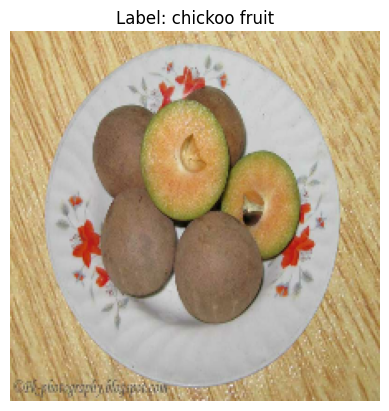

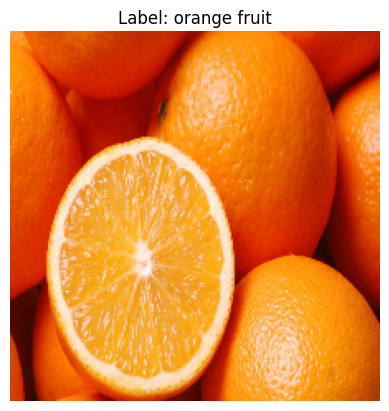

In [9]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

In [17]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
      keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [18]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1020 - loss: 40.0569 - val_accuracy: 0.0833 - val_loss: 26.8585
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 993ms/step - accuracy: 0.1647 - loss: 17.5685 - val_accuracy: 0.1833 - val_loss: 10.2835
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3059 - loss: 6.1463 - val_accuracy: 0.1500 - val_loss: 6.0969
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2941 - loss: 3.7518 - val_accuracy: 0.1833 - val_loss: 3.4930
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 980ms/step - accuracy: 0.3686 - loss: 2.7939 - val_accuracy: 0.1833 - val_loss: 3.6620
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 978ms/step - accuracy: 0.4157 - loss: 2.4518 - val_accuracy: 0.1667 - val_loss: 3.5831
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 976ms/step - accuracy: 0.4588 - loss: 2.3053 - val_accuracy: 0.1833 - val_loss: 3.6802
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step - accuracy: 0.5412 - loss: 1.6075 - val_accuracy: 0.

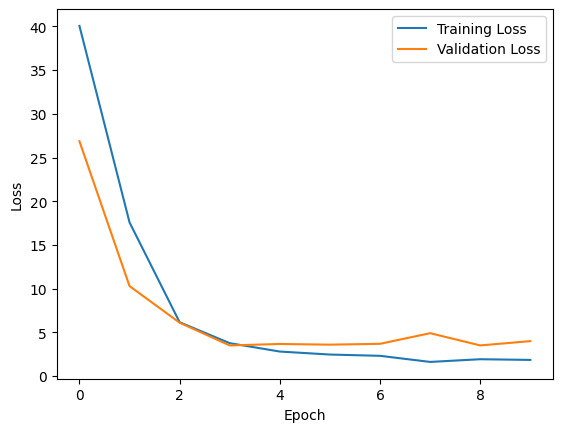

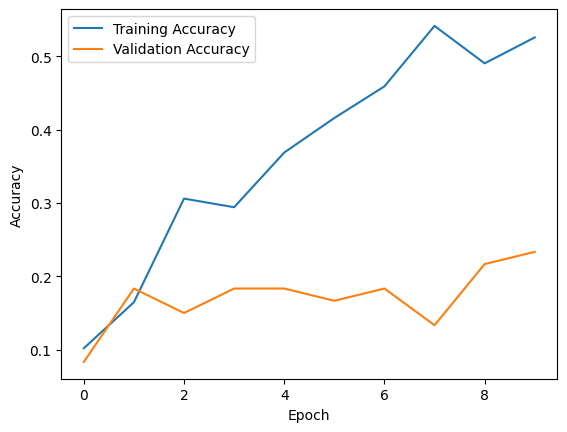

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


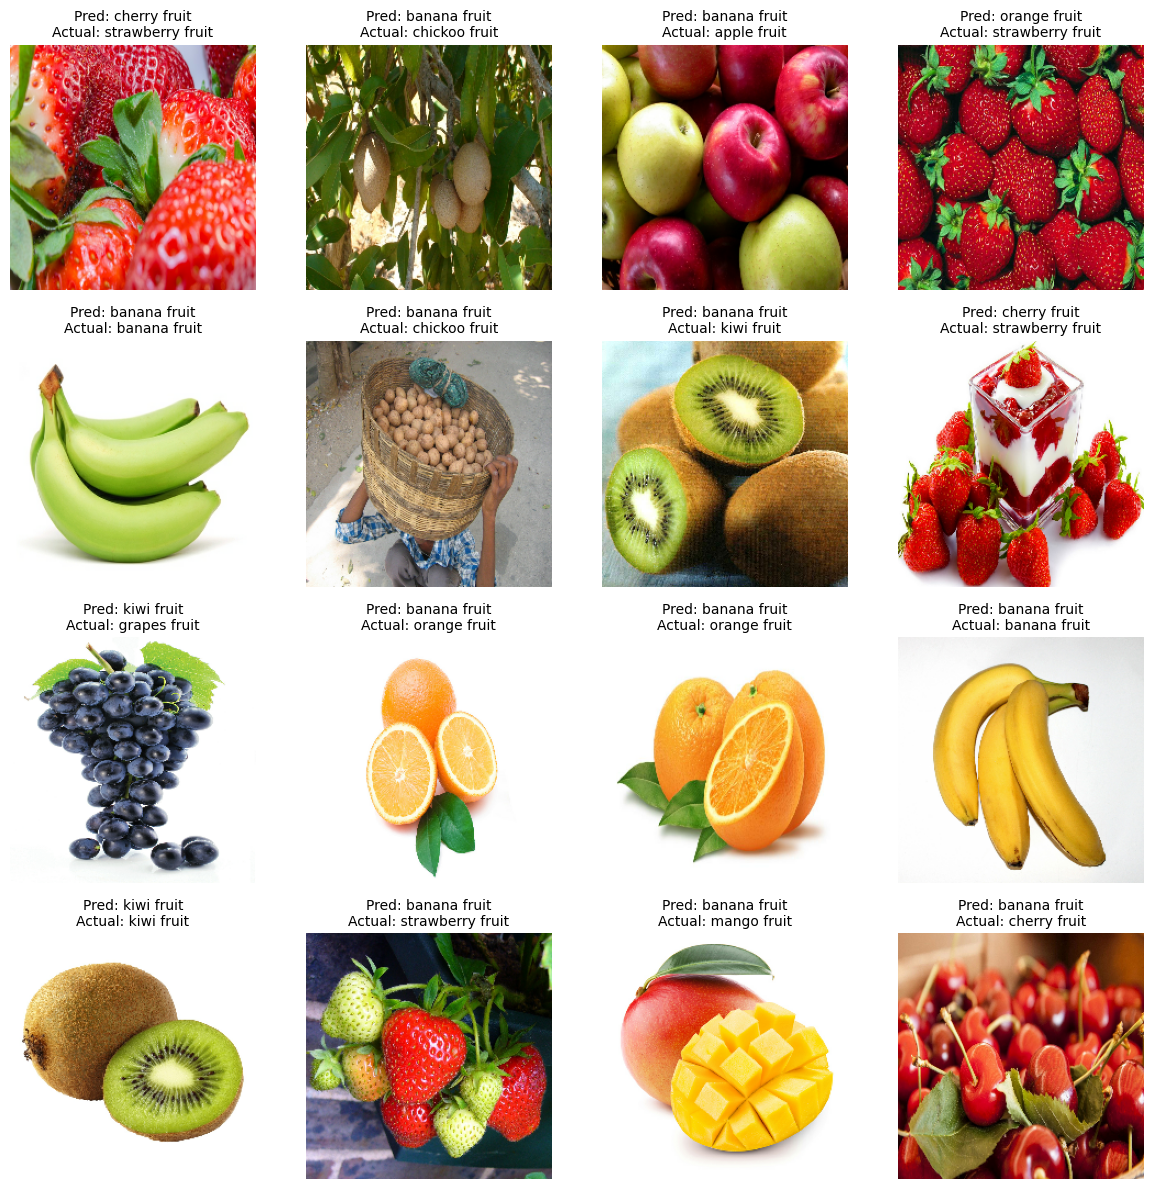

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math

for images, labels in eval_dataset.take(1):

    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    num_images = images.shape[0]

    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)


        plt.imshow(images[i].numpy())
        plt.axis('off')

        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    plt.tight_layout()
    plt.show()